In [1]:
import matplotlib.pyplot as plt
import numpy as np
import re

In [2]:
day08_inputs = "inputs/day08.txt"

with open(day08_inputs) as file:
    day08_instructions = file.readlines()
day08_instructions = [line.strip() for line in day08_instructions]

In [3]:
screen_array = np.zeros((6,50)) # 50 pixels wide, 6 pixels tall
for instruction in day08_instructions:
    instruct_split = instruction.split(" ")
    
    if instruct_split[0] == "rect":
        rect_size_string = instruct_split[1]
        rect_size_match = re.match(r"(\d+)x(\d+)", rect_size_string)
        
        width, height = map(int, rect_size_match.groups())
        screen_array[0:height, 0:width] = 1
    if instruct_split[0] == "rotate":
        rotation_axis = instruct_split[1]
        rot_row_or_col_match = re.search(r"=(\d+)", instruct_split[2])

        slices = [slice(None), slice(None)]
        rot_axis = (0 if rotation_axis == "row" else 1)
        slices[rot_axis] = int(rot_row_or_col_match.group(1))

        indexed_data = screen_array[tuple(slices)]
        indexed_data_rolled = np.roll(indexed_data, instruct_split[-1])
        screen_array[tuple(slices)] = indexed_data_rolled
        
print(screen_array)
on_pixels = len(np.where(screen_array == 1)[0])
print(f'part1: there are {on_pixels} "on" pixels')

[[1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1. 0.
  0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1. 1.
  0. 0.]
 [1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1.
  0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0.
  1. 0.]
 [1. 1. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0.
  0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0.
  1. 0.]
 [1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 0. 1. 1.
  0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0.
  1. 0.]
 [1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1.
  0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0.
  1. 0.]
 [1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 1. 1.
  0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1.
  0. 0.]]
part1: there are 128 "on" pixels


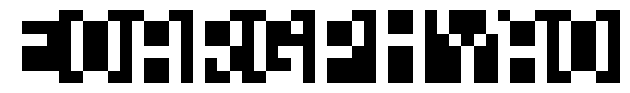

In [4]:
fig, ax = plt.subplots()
im = ax.imshow(screen_array, cmap=plt.cm.gnuplot2)
plt.axis('off')
fig.tight_layout()
plt.show()

In [5]:
# part2: "EOARGPHYAO" is the code